# Example code for connecting a Sciospec device

## EIT device

**USB-HS**

If you have issues with the connection try [this](https://eblot.github.io/pyftdi/installation.html).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import savemat

from sciopy import EIT_16_32_64_128, EitMeasurementSetup

In [2]:
# create a 'sciospec' class which represents the sciospec EIT device
n_el = 32
sciospec = EIT_16_32_64_128(n_el)

In [3]:
# connect device via USB-HS port
sciospec.connect_device_HS()

In [4]:
# read system message buffer
sciospec.SystemMessageCallback()
# should be empty

No message inside the message buffer
message buffer:
 ['0x18', '0x1', '0x4', '0x18', '0x18', '0x1', '0x84', '0x18']
message length:	 8


In [5]:
# get device info
sciospec.GetDeviceInfo()

Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0xd1', '0x14', '0x1', '0x0', '0x19', '0x2', '0x65', '0x10', '0x3', '0x3', '0x0', '0x21', '0x0', '0x8d', '0x0', '0xba', '0x0', '0xe4', '0x0', '0xba', '0x0', '0xe4', '0xd1', '0x18', '0x1', '0x83', '0x18']
message length:	 27


In [6]:
# create a measurement setup
setup = EitMeasurementSetup(
    burst_count=1,
    n_el=n_el,
    exc_freq=1_000,
    framerate=50,
    amplitude=0.01,
    inj_skip=0,
    gain=1,
    adc_range=1,
)

In [7]:
sciospec.SetMeasurementSetup(setup)

Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4


In [8]:
# look inside the docstring of the function and manual
sciospec.GetMeasurementSetup(2)

TBD (to be checked)
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0xb1', '0x3', '0x2', '0x0', '0x1', '0xb1', '0x18', '0x1', '0x83', '0x18']
message length:	 10
TBD: Translation


In [9]:
sciospec.update_BurstCount(100)

In [10]:
# get data
data_0 = sciospec.StartStopMeasurement(return_as="pot_mat")  # or "hex"
# data.shape = (burst_count, n_el, n_el)
# check if data shape equals setup
assert data_0.shape[0] == setup.burst_count

In [11]:
#indeces = np.arange(0,1024)
#skip_pos = np.arange(0,1024,33)
#skip_neg = np.arange(1,1024,33)
#mask = ~np.isin(indeces,np.concatenate((skip_pos, skip_neg)))



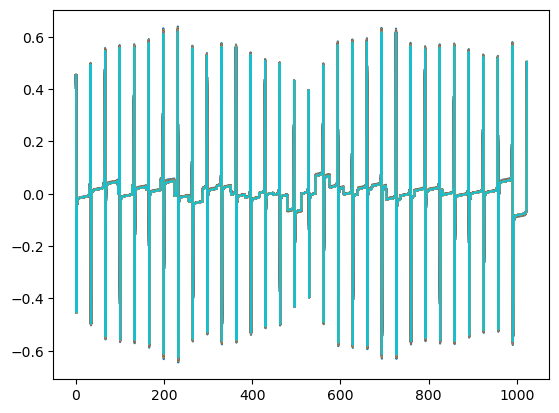

In [12]:
for pot in data_0:
    plt.plot(np.real(pot.flatten()))

In [13]:
savemat("experiment_reference.mat", {"data": data_0})

Change something on the phantom

In [14]:
# get data
data_1 = sciospec.StartStopMeasurement(return_as="pot_mat")  # or "hex"
# data.shape = (burst_count, n_el, n_el)
# check if data shape equals setup
assert data_1.shape[0] == setup.burst_count

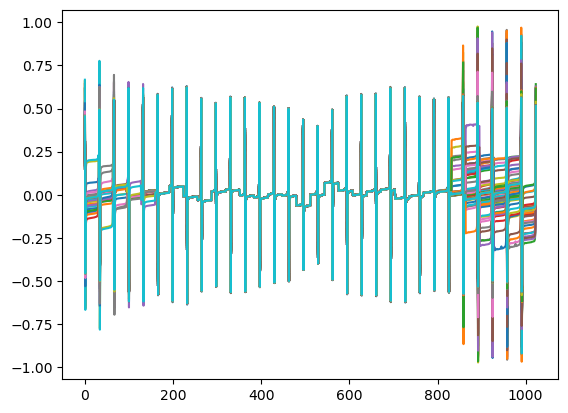

In [15]:
for pot in data_1:
    plt.plot(np.real(pot.flatten()))
    #plt.xlim([990,1024])

In [16]:
savemat("experiment_target_1.mat", {"data": data_1})

Change something on the phantom

In [17]:
# get data
data_2 = sciospec.StartStopMeasurement(return_as="pot_mat")  # or "hex"
# data.shape = (burst_count, n_el, n_el)
# check if data shape equals setup
assert data_2.shape[0] == setup.burst_count

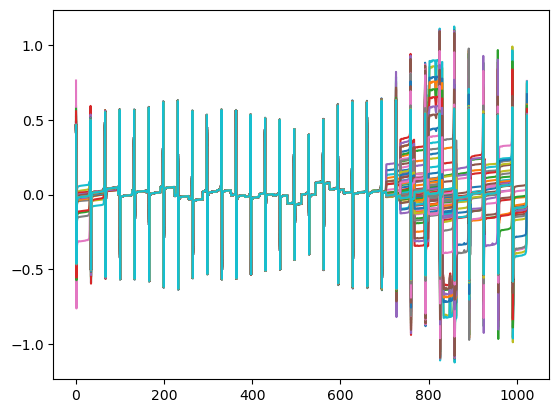

In [18]:
for pot in data_2:
    plt.plot(np.real(pot.flatten()))
    #plt.xlim([990,1024])

In [21]:
dir sciospec

SyntaxError: invalid syntax (490382248.py, line 1)

In [19]:
savemat("experiment_target_2.mat", {"data": data_2, "amp": amplitude, "framerate":framerate})

NameError: name 'amplitude' is not defined

In [ ]:
plt.imshow(np.real(data_2[0,:,:]))

In [ ]:
data.shape